# Analysis of Mother Mortality in Australia

We will examine a large dataset centered on Australia's historical maternal mortality ratios in this portfolio task. The Kaggle dataset includes several socioeconomic indicators that could affect maternal health results. Our main goal is to investigate patterns in maternal death rates and pinpoint important variables related to these rates. The dataset contains factors like education levels, access to health care, economic indicators, and demographic information. By doing this analysis, we want to gain important insights into public health policy and intervention initiatives by training predictive models to estimate maternal mortality rates and assessing the benefits and drawbacks of these models.

There are over 1000s of features in this dataset. Glimpses of some features are

|Columns||
|:-----:|:-----:|
|year|
|Intentional homicides, female (per 100,000 female)|
|Battle-related deaths (number of people)|
|School enrollment|
|tertiary (gross)|
|gender parity index (GPI)|
|Short-term debt (% of total reserves)|
|Net ODA received (% of gross capital formation)|
|Subsidies and other transfers (% of expense)|
|.|
|.|
|.|
|.|
|.|
|PPP (current international $)|
|Coverage of social insurance programs in 2nd quintile (% of population)|


In [9]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error as mse, r2_score as r2, mean_absolute_error as mae, mean_absolute_percentage_error as mape

file_path = 'australia_economic.csv'
australia_data = pd.read_csv(file_path)
print(australia_data.head())
print(australia_data.info())
rmse=lambda y,yp: mse(y,yp,squared=False)
def eval_print(m,Xtr,ytr,Xv,yv,name):
    yp_tr, yp = m.predict(Xtr), m.predict(Xv)
    print(f"{name} -> Train RMSE {rmse(ytr,yp_tr):,.2f} | Val RMSE {rmse(yv,yp):,.2f} | Val R² {r2(yv,yp):.3f}")
    print(f"{name} -> Train MAE {mae(ytr,yp_tr):,.2f} | Val MAE {mae(yv,yp):,.2f} | Val MAPE {mape(yv,yp):.3%}")


   year  Intentional homicides, female (per 100,000 female)  \
0  1960                                                NaN    
1  1961                                                NaN    
2  1962                                                NaN    
3  1963                                                NaN    
4  1964                                                NaN    

   Battle-related deaths (number of people)  \
0                                       NaN   
1                                       NaN   
2                                       NaN   
3                                       NaN   
4                                       NaN   

   Voice and Accountability: Percentile Rank  \
0                                        NaN   
1                                        NaN   
2                                        NaN   
3                                        NaN   
4                                        NaN   

   Transport services (% of commercial service ex

### Feature Visualisation

c:\Users\dhruv\anaconda3\Lib\site-packages\sklearn\impute\_base.py:577: UserWarning: Skipping features without any observed values: ['Unmet need for contraception (% of married women ages 15-49)'
 'Female headed households (% of households with a female head)'
 'Consumption of iodized salt (% of households)'
 'People with basic handwashing facilities including soap and water (% of population)'
 'Incidence of malaria (per 1,000 population at risk)'
 'Children (0-14) living with HIV'
 'Condom use, population ages 15-24, female (% of females ages 15-24)'
 'Women who believe a husband is justified in beating his wife (any of five reasons) (%)'
 'Women who believe a husband is justified in beating his wife when she argues with him (%)'
 'Trained teachers in upper secondary education (% of total teachers)'
 'Trained teachers in lower secondary education (% of total teachers)'
 'Progression to secondary school (%)'
 'Pupil-teacher ratio, upper secondary'
 'Trained teachers in primary educatio

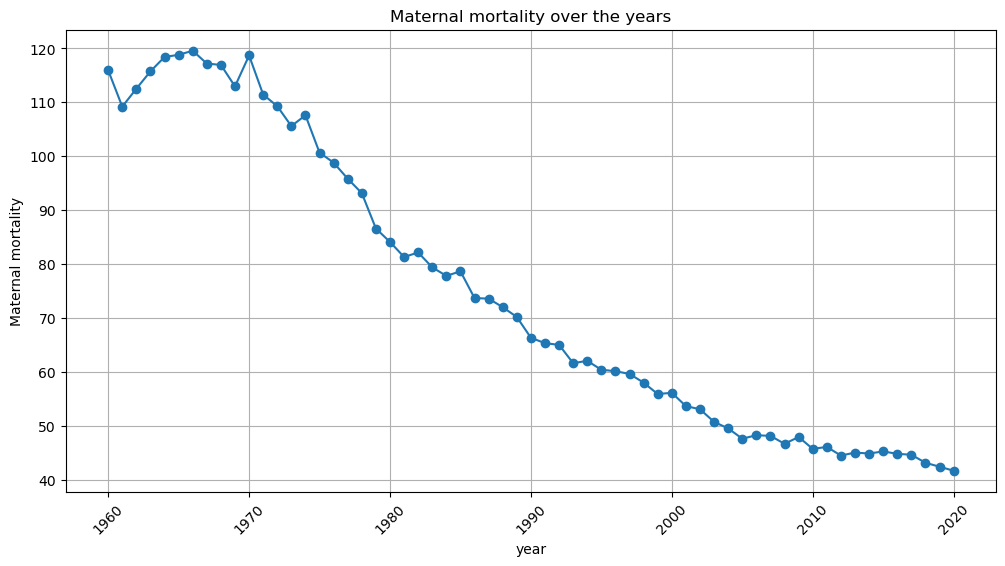

In [11]:
target_variable = "Mortality rate, adult, female (per 1,000 female adults)"

if target_variable in australia_data.columns:
    X = australia_data.drop(columns=['year', target_variable])
    y = australia_data[target_variable]
    imputer = SimpleImputer(strategy='mean')
    X = imputer.fit_transform(X)
    y = imputer.fit_transform(y.values.reshape(-1, 1)).ravel()
    plt.figure(figsize=(12, 6))
    plt.plot(australia_data['year'], australia_data[target_variable], marker='o')
    plt.title('Maternal mortality over the years')
    plt.xlabel('year')
    plt.ylabel('Maternal mortality')
    plt.xticks(rotation=45)
    plt.grid()
    plt.show()

### Data Cleansing

In [12]:
missing_frac = australia_data.isna().mean()
cols_drop_missing = missing_frac[missing_frac > 0.50].index.tolist()

print(f"Dropping {len(cols_drop_missing)} columns with >50% missing values.")
data_reduced = australia_data.drop(columns=cols_drop_missing)

data_for_plot = data_reduced[['year', target_variable]].copy() if 'year' in data_reduced.columns else None

data_model = data_reduced.drop(columns=['year'], errors="ignore")

data_model_imputed = data_model.fillna(data_model.mean(numeric_only=True))

print("Missing values after impute (should be 0):")
print(data_model_imputed.isnull().sum().sum())

Dropping 878 columns with >50% missing values.
Missing values after impute (should be 0):
0


### Data Selection

In [13]:
TOP_K = 30                
MIN_ABS_CORR = 0.35     
CORR_METHOD = "pearson"   

corr_series = (
    data_model_imputed
    .corr(method=CORR_METHOD, numeric_only=True)[target_variable]
    .drop(labels=[target_variable])
    .dropna()
)

corr_sorted = corr_series.reindex(corr_series.abs().sort_values(ascending=False).index)

print("\nTop correlated features (abs-sorted):")
print(corr_sorted.head(30))

if MIN_ABS_CORR is not None:
    selected_features = corr_sorted[corr_sorted.abs() >= MIN_ABS_CORR].index.tolist()
    print(f"\nSelected {len(selected_features)} features with |corr| >= {MIN_ABS_CORR}")
else:
    selected_features = corr_sorted.head(TOP_K).index.tolist()
    print(f"\nSelected TOP_K={TOP_K} features by |corr|")

selected_features = [c for c in selected_features if c in data_model_imputed.columns]
if len(selected_features) == 0:
    raise ValueError("No features selected. Lower MIN_ABS_CORR or increase TOP_K.")


Top correlated features (abs-sorted):
Mortality rate, adult, male (per 1,000 male adults)                  0.994679
Mortality rate, infant, male (per 1,000 live births)                 0.980168
Mortality rate, infant (per 1,000 live births)                       0.979850
Mortality rate, under-5, male (per 1,000 live births)                0.979814
Survival to age 65, female (% of cohort)                            -0.979724
Mortality rate, under-5 (per 1,000 live births)                      0.979120
Mortality rate, infant, female (per 1,000 live births)               0.978751
Mortality rate, under-5, female (per 1,000 live births)              0.977840
Life expectancy at birth, female (years)                            -0.973344
Number of under-five deaths                                          0.972226
Age dependency ratio, young (% of working-age population)            0.972063
Number of infant deaths                                              0.969692
Population ages 0-14, fem

### Features Plotting

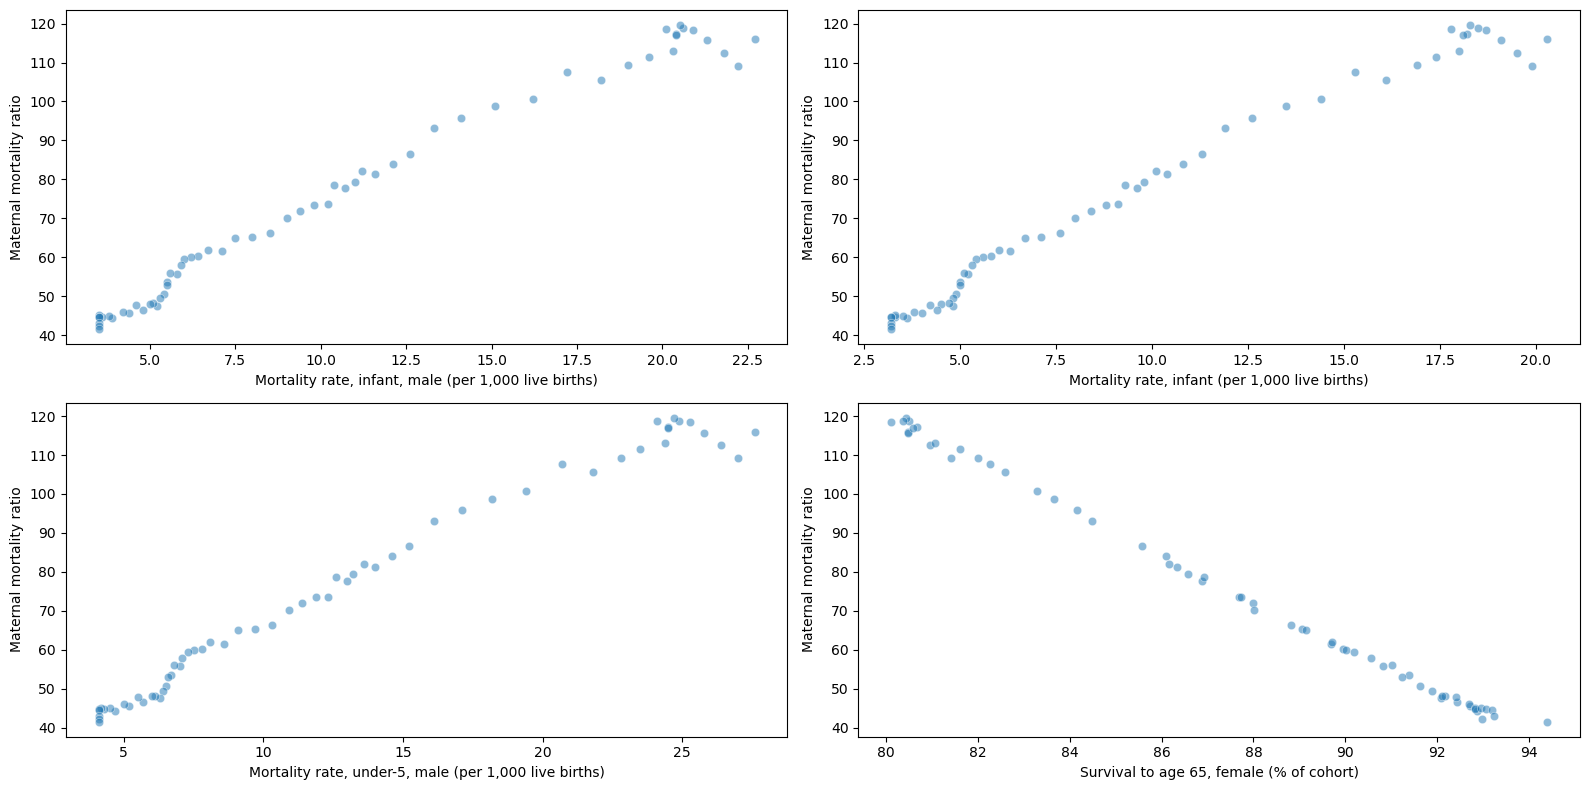

In [17]:
features_eg = selected_features[1:5]  
plt.figure(figsize=(16, 8))

for i, feature_eg in enumerate(features_eg):
    plt.subplot(2, (len(features_eg) + 1) // 2, i + 1)  
    sns.scatterplot(x=feature_eg, y=target_variable, data=australia_data, alpha=0.5)
    plt.xlabel(feature_eg)  
    plt.ylabel('Maternal mortality ratio')  

plt.tight_layout()  
plt.show()
    


### Data Split

In [18]:
target_variable = "Mortality rate, adult, female (per 1,000 female adults)"
X = data_model_imputed.drop(columns=[target_variable])
y = data_model_imputed[target_variable]
X = X[selected_features]
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)  
y = imputer.fit_transform(y.values.reshape(-1, 1)).ravel()  
scaler = StandardScaler()
X = scaler.fit_transform(X)  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Artificial Neural Network

c:\Users\dhruv\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\dhruv\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\dhruv\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\dhruv\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\dhruv\anaconda3\Lib\site-packages\sklearn\neural_network\_m

Training Mean Squared Error (Neural Network): 0.6707820706525635
Test Mean Squared Error (Neural Network): 30.337820234813194
Neural Network -> Train RMSE 0.82 | Val RMSE 5.51 | Val R² 0.963
Neural Network -> Train MAE 0.66 | Val MAE 4.23 | Val MAPE 5.351%


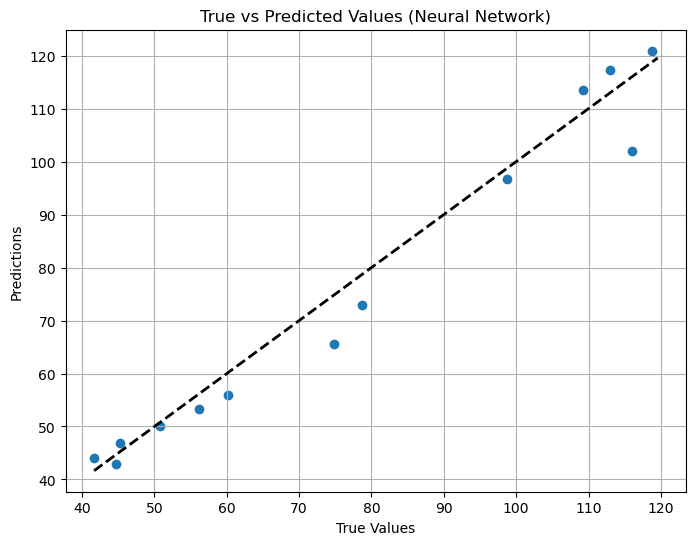

Best parameters found: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (50,), 'solver': 'adam'}


In [20]:
nn_model = MLPRegressor(max_iter=1000, random_state=42)
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01], 
}
grid_search = GridSearchCV(nn_model, param_grid, scoring='neg_mean_squared_error', cv=5)
grid_search.fit(X_train, y_train)
best_nn_model = grid_search.best_estimator_
train_predictions = best_nn_model.predict(X_train)
test_predictions = best_nn_model.predict(X_test)
train_mse = mean_squared_error(y_train, train_predictions)
test_mse = mean_squared_error(y_test, test_predictions)
print("Training Mean Squared Error (Neural Network):", train_mse)
print("Test Mean Squared Error (Neural Network):", test_mse)
eval_print(best_nn_model, X_train, y_train, X_test, y_test, "Neural Network")
plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_predictions)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values (Neural Network)')
plt.grid()
plt.show()
print("Best parameters found:", grid_search.best_params_)


### Decision Tree

In [22]:
decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train, y_train)
train_predictions = decision_tree_model.predict(X_train)
test_predictions = decision_tree_model.predict(X_test)
train_mse = mean_squared_error(y_train, train_predictions)
test_mse = mean_squared_error(y_test, test_predictions)
# print("Training Mean Squared Error (Decision Tree):", train_mse)
# print("Test Mean Squared Error (Decision Tree):", test_mse)
eval_print(decision_tree_model, X_train, y_train, X_test, y_test, "Decision Tree")

Decision Tree -> Train RMSE 0.00 | Val RMSE 9.44 | Val R² 0.893
Decision Tree -> Train MAE 0.00 | Val MAE 4.57 | Val MAPE 5.732%


c:\Users\dhruv\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\dhruv\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# Random Forest

In [23]:
rf = RandomForestRegressor(n_jobs=-1, random_state=42)
param_rf = {"n_estimators":[150,250,350],"max_depth":[None,8,12],
            "min_samples_leaf":[1,2,4],"max_features":["sqrt",0.6,1.0]}
rf_search = RandomizedSearchCV(rf, param_rf, n_iter=12, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose=1)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
print("RF best:", rf_search.best_params_, "CV RMSE:", -rf_search.best_score_)
eval_print(best_rf, X_train, y_train, X_test, y_test, "RF (tuned)")


Fitting 3 folds for each of 12 candidates, totalling 36 fits
RF best: {'n_estimators': 150, 'min_samples_leaf': 2, 'max_features': 0.6, 'max_depth': 12} CV RMSE: 4.203035716701604
RF (tuned) -> Train RMSE 1.25 | Val RMSE 7.44 | Val R² 0.933
RF (tuned) -> Train MAE 0.74 | Val MAE 3.80 | Val MAPE 5.260%


c:\Users\dhruv\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\dhruv\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# XGBoost

In [24]:
model = XGBRegressor(objective="reg:squarederror", n_estimators=300, tree_method="hist", n_jobs=-1)
param = {"model__max_depth":[3,5,7],"model__learning_rate":[0.01,0.05,0.1],
        "model__subsample":[0.7,0.85,1.0],"model__colsample_bytree":[0.7,0.85,1.0],
        "model__min_child_weight":[1,3,5],"model__n_estimators":[200,300,500]}
search = RandomizedSearchCV(model, param, n_iter=16, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose=1)
name="XGB (tuned)"
search.fit(X_train,y_train)
best_boost = search.best_estimator_
print(name, "best:", search.best_params_, "CV RMSE:", -search.best_score_)
eval_print(best_boost, X_train, y_train, X_test, y_test, name)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


c:\Users\dhruv\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:29:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "model__colsample_bytree", "model__learning_rate", "model__max_depth", "model__min_child_weight", "model__n_estimators", "model__subsample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB (tuned) best: {'model__subsample': 0.7, 'model__n_estimators': 300, 'model__min_child_weight': 3, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.85} CV RMSE: 2.8720407491707967
XGB (tuned) -> Train RMSE 0.00 | Val RMSE 2.54 | Val R² 0.992
XGB (tuned) -> Train MAE 0.00 | Val MAE 1.84 | Val MAPE 2.456%


c:\Users\dhruv\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\dhruv\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
